1.Data Loading & Exploratory Analysis

(7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    


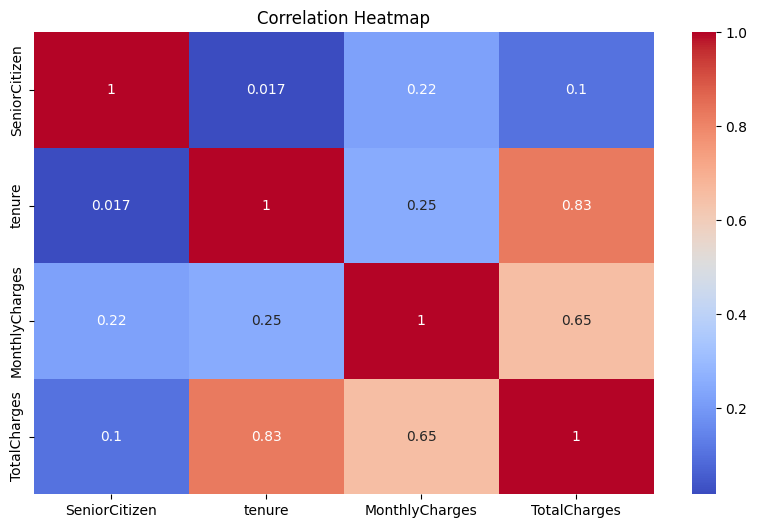

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
print(df.info())
print(df.head(10))
print(df['Churn'].value_counts(normalize=True))
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df.describe())
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

2.Data Preprocessing & Feature Engineering

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)
df['ChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1e-9)
df['SeniorWithNoSupport'] = ((df['SeniorCitizen'] == 1) & (df['TechSupport'] == 'No')).astype(int)
X = df.drop(columns=['Churn', 'customerID'])
y = df['Churn'].map({'Yes': 1, 'No': 0})
cat_cols = X.select_dtypes(include=['object', 'category', 'string']).columns
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

3.Model Training & Comparison


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

ROC-AUC: 0.8360

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.50      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8159

--- XGBoost ---
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      1033
           1       0.56      0.50      0.53       374

    accuracy                           0.76      1407
   macro avg       0.69    

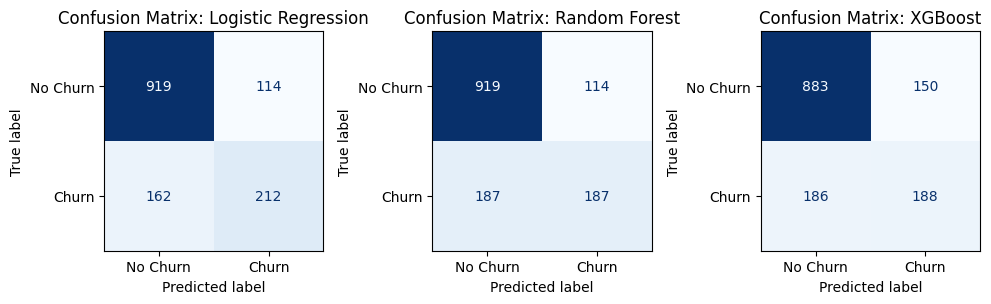

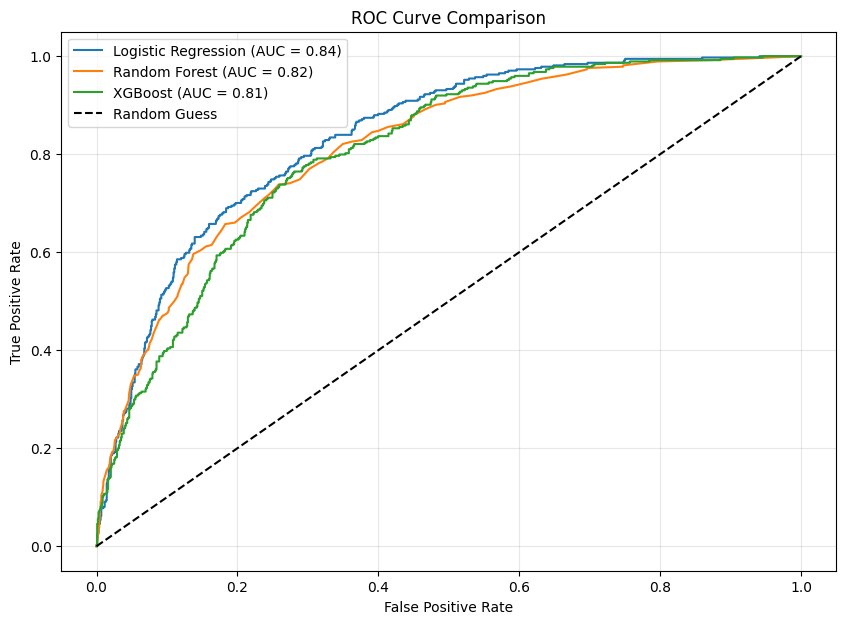

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters Found:
{'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}

--- Tuned Random Forest Performance ---
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

Tuned ROC-AUC: 0.8330


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score, classification_report
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {'y_pred': y_pred, 'y_prob': y_prob, 'model': model}
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(10, 6))

for i, (name, data) in enumerate(results.items()):
    cm = confusion_matrix(y_test, data['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"Confusion Matrix: {name}")

plt.tight_layout()
#plt.savefig('charts/confusion_matrices.png') # For submission
plt.show()
plt.figure(figsize=(10, 7))

for name, data in results.items():
    fpr, tpr, _ = roc_curve(y_test, data['y_prob'])
    auc_score = roc_auc_score(y_test, data['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)
#plt.savefig('charts/model_comparison.png') # Required for submission[cite: 1]
plt.show()
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
param_grid = {
    'n_estimators': [100, 200],      
    'max_depth': [10, 20, None],     
    'min_samples_split': [2, 5],     
    'criterion': ['gini', 'entropy']
}
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,  
    verbose=1
)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
best_rf_model = grid_search.best_estimator_
print("Best Parameters Found:")
print(best_params)
from sklearn.metrics import classification_report, roc_auc_score
tuned_probs = best_rf_model.predict_proba(X_test)[:, 1]
print("\n--- Tuned Random Forest Performance ---")
print(classification_report(y_test, best_rf_model.predict(X_test)))
print(f"Tuned ROC-AUC: {roc_auc_score(y_test, tuned_probs):.4f}")

4.Customer Risk Segmentation

In [6]:
best_model = models["XGBoost"]
df_test_results = X_test.copy()
df_test_results['Churn_Prob'] = best_model.predict_proba(X_test)[:, 1]
def segment_risk(prob):
    if prob >= 0.70: 
        return 'High Risk'
    elif prob >= 0.40: 
        return 'Medium Risk'
    else: 
        return 'Low Risk'
df_test_results['Risk_Tier'] = df_test_results['Churn_Prob'].apply(segment_risk)

print(df_test_results['Risk_Tier'].value_counts())

Risk_Tier
Low Risk       985
Medium Risk    242
High Risk      180
Name: count, dtype: int64


5.Visualizations

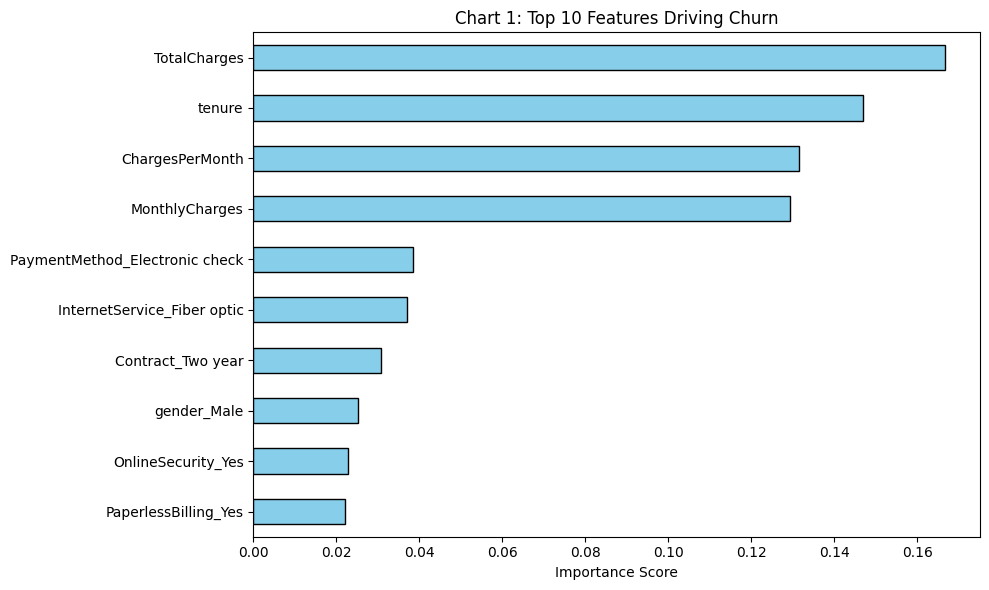

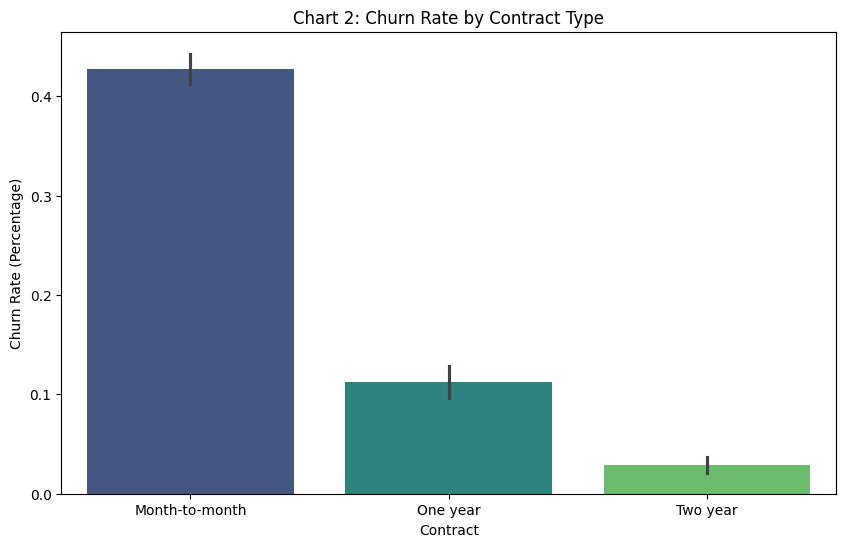

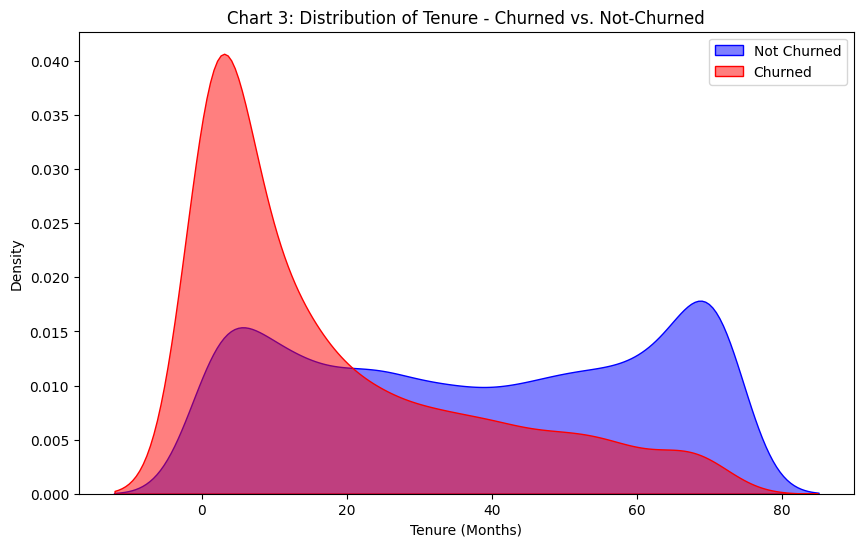

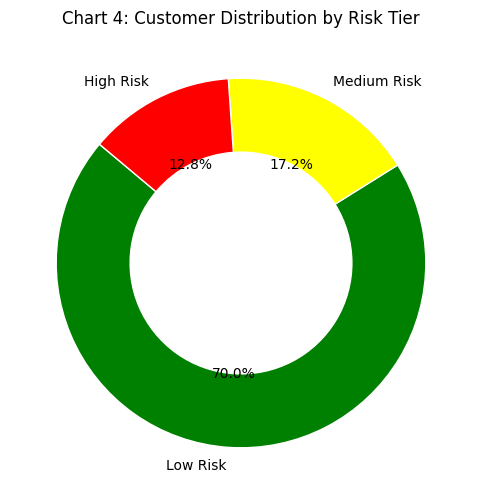

In [7]:
best_model = models["Random Forest"]
importances = best_model.feature_importances_
feat_importances = pd.Series(importances, index=X_encoded.columns).sort_values(ascending=True).tail(10)
plt.figure(figsize=(10, 6))
feat_importances.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title("Chart 1: Top 10 Features Driving Churn")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 6))
sns.barplot(x='Contract', y=(df['Churn']== 'Yes').astype(int), data=df, palette='viridis', hue='Contract',legend=False)
plt.title("Chart 2: Churn Rate by Contract Type")
plt.ylabel("Churn Rate (Percentage)")
plt.show()
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['Churn'] == 'No']['tenure'], label='Not Churned', fill=True, color='blue', alpha=0.5)
sns.kdeplot(df[df['Churn'] == 'Yes']['tenure'], label='Churned', fill=True, color='red', alpha=0.5)
plt.title("Chart 3: Distribution of Tenure - Churned vs. Not-Churned")
plt.xlabel("Tenure (Months)")
plt.legend()
plt.show()
color_map = {'High Risk': '#FF0000', 'Medium Risk': '#FFFF00', 'Low Risk': '#008000'}
tier_counts = df_test_results['Risk_Tier'].value_counts()
colors = [color_map[label] for label in tier_counts.index]
plt.figure(figsize=(8, 6))
tier_counts.plot.pie(autopct='%1.1f%%', colors=colors, startangle=140, 
                    wedgeprops=dict(width=0.4, edgecolor='white'))
plt.title("Chart 4: Customer Distribution by Risk Tier")
plt.ylabel("")
plt.show()
import plotly.express as px
fig = px.scatter(df.sample(1000), x="tenure", y="MonthlyCharges", color="Churn",
                 title="Bonus: Monthly Charges vs. Tenure by Churn Label",
                 labels={"tenure": "Tenure (Months)", "MonthlyCharges": "Monthly Charges ($)"},
                 color_discrete_map={"Yes": "red", "No": "blue"},
                 opacity=0.6)

fig.show()

6.Insights & Business Recommendations

->Best Performing Model: Logistic Regression was the most effective model, achieving an ROC-AUC of 0.84. It was selected because it identified the highest number of actual churners (212) in the confusion matrix.

->Top 3 Churn Drivers: According to the feature importance analysis, the primary factors are Total Charges, Tenure, and Charges Per Month.

->High-Risk Customer Profile: High-risk customers typically have short tenure (under 12 months), use Month-to-Month contracts, and pay higher Monthly Charges.

->Requirement 1:Implement a retention program for customers in their first 6 months, as the tenure distribution shows a massive spike in churn during this early period.
Requirement 2:Offer incentives to migrate Month-to-Month customers to One-year contracts, which showed significantly lower churn rates in the bar charts.

->Model Limitations: The primary limitation is class imbalance, which leads to lower Recall. The model could be improved with more data on customer service interactions or by using SMOTE techniques to balance the training set.
Future Improvements: Performance could be improved by collecting customer satisfaction scores or support ticket history, and by utilizing SMOTE to balance the training data.